In [3]:
import os
from google.colab import files

print("unggah file kaggle.json:")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API berhasil disiapkan!")

unggah file kaggle.json:


Saving kaggle.json to kaggle.json
Kaggle API berhasil disiapkan!


In [4]:
!kaggle datasets download -d misrakahmed/vegetable-image-dataset

Dataset URL: https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset
License(s): CC-BY-SA-4.0
 97% 516M/534M [00:03<00:00, 92.5MB/s]
100% 534M/534M [00:03<00:00, 177MB/s] 


In [5]:
import zipfile

local_zip = '/content/vegetable-image-dataset.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')

# Mengekstrak semua isi zip ke dalam folder bernama 'dataset'
zip_ref.extractall('/content/dataset')
zip_ref.close()

print("Dataset berhasil diekstrak ke folder /content/dataset !")

Dataset berhasil diekstrak ke folder /content/dataset !


In [6]:
!pip install split-folders

import splitfolders
import os

# Mengambil folder train
source_dir = '/content/dataset/Vegetable Images/train'

# Menyiapkan folder baru
output_dir = '/content/split_dataset'

print("Sedang membagi dataset secara manual...\n")

# pembagian data secara acak dengan rasio 80% Train, 10% Val, 10% Test
splitfolders.ratio(source_dir, output=output_dir, seed=42, ratio=(0.8, 0.1, 0.1))

# Mendefinisikan ulang path direktori oleh ImageDataGenerator
train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')
test_dir = os.path.join(output_dir, 'test')

print("\nBerhasil! Dataset telah dibagi manual menjadi Train, Val, dan Test di folder:", output_dir)
print("Daftar kelas di folder train baru:", os.listdir(train_dir))

Sedang membagi dataset secara manual...



Copying files: 15000 files [00:02, 5626.94 files/s]


Berhasil! Dataset telah dibagi manual menjadi Train, Val, dan Test di folder: /content/split_dataset
Daftar kelas di folder train baru: ['Brinjal', 'Potato', 'Capsicum', 'Bitter_Gourd', 'Bottle_Gourd', 'Bean', 'Papaya', 'Cabbage', 'Cauliflower', 'Pumpkin', 'Broccoli', 'Radish', 'Carrot', 'Tomato', 'Cucumber']


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Resolusi gambar seragam untuk memperingan komputasi
IMG_WIDTH = 150
IMG_HEIGHT = 150
BATCH_SIZE = 64

# Augmentasi khusus data latih
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)

# rescale untuk data validasi dan testing
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("Menyiapkan Data Generator...\n")

# Menyiapkan generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Menyiapkan Data Generator...

Found 12000 images belonging to 15 classes.
Found 1500 images belonging to 15 classes.
Found 1500 images belonging to 15 classes.


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Membangun model Sequential
model = Sequential([
    # Layer Konvolusi 1
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    # Layer Konvolusi 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Layer Konvolusi 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Layer Konvolusi 4
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Meratakan fitur menjadi 1 dimensi
    Flatten(),

    # Hidden layer dengan Dropout
    Dropout(0.5),
    Dense(512, activation='relu'),

    # Output layer: 15
    Dense(15, activation='softmax')
])

# optimizer dan loss function
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# ringkasan arsitektur model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,460,303 (13.20 MB)

 Trainable params: 3,460,303 (13.20 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
import tensorflow as tf

# class callback
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    # Mengecek apakah akurasi training dan validasi sudah di atas 95%
    if(logs.get('accuracy') > 0.96 and logs.get('val_accuracy') > 0.96):
      print("Target akurasi > 95% telah tercapai, menghentikan training otomatis!")
      self.model.stop_training = True

# Menginisialisasi objek callback
callbacks = myCallback()

In [10]:
EPOCHS = 30

print("Memulai proses training model dengan Callback...\n")

# Memulai proses training
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    verbose=1,
    callbacks=[callbacks]
)

Memulai proses training model dengan Callback...



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 94s 434ms/step - accuracy: 0.3066 - loss: 2.0150 - val_accuracy: 0.6889 - val_loss: 0.9713
Epoch 2/30
  1/187 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.6719 - loss: 1.1246

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6719 - loss: 1.1246 - val_accuracy: 0.6943 - val_loss: 0.9567
Epoch 3/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 76s 406ms/step - accuracy: 0.6795 - loss: 0.9546 - val_accuracy: 0.7126 - val_loss: 0.8020
Epoch 4/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6875 - loss: 0.8313 - val_accuracy: 0.7446 - val_loss: 0.7359
Epoch 5/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 71s 381ms/step - accuracy: 0.7883 - loss: 0.6092 - val_accuracy: 0.8363 - val_loss: 0.5107
Epoch 6/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7969 - loss: 0.5025 - val_accuracy: 0.8030 - val_loss: 0.6226
Epoch 7/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 73s 388ms/step - accuracy: 0.8481 - loss: 0.4515 - val_accuracy: 0.9042 - val_loss: 0.3024
Epoch 8/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9375 - loss: 0.2091 - val_accuracy: 0.8893 - val_loss: 0.3745
Epoch 9/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 71s 381ms/step - accuracy: 0.8804 - loss: 0.3547 - val_accuracy: 

Sedang mengevaluasi data test untuk mendapatkan hasil akhir...

HASIL AKHIR EVALUASI MODEL
Data Training   -> Akurasi: 96.48% | Loss: 0.1127
Data Validation -> Akurasi: 97.42% | Loss: 0.1045
Data Testing    -> Akurasi: 96.80% | Loss: 0.1313



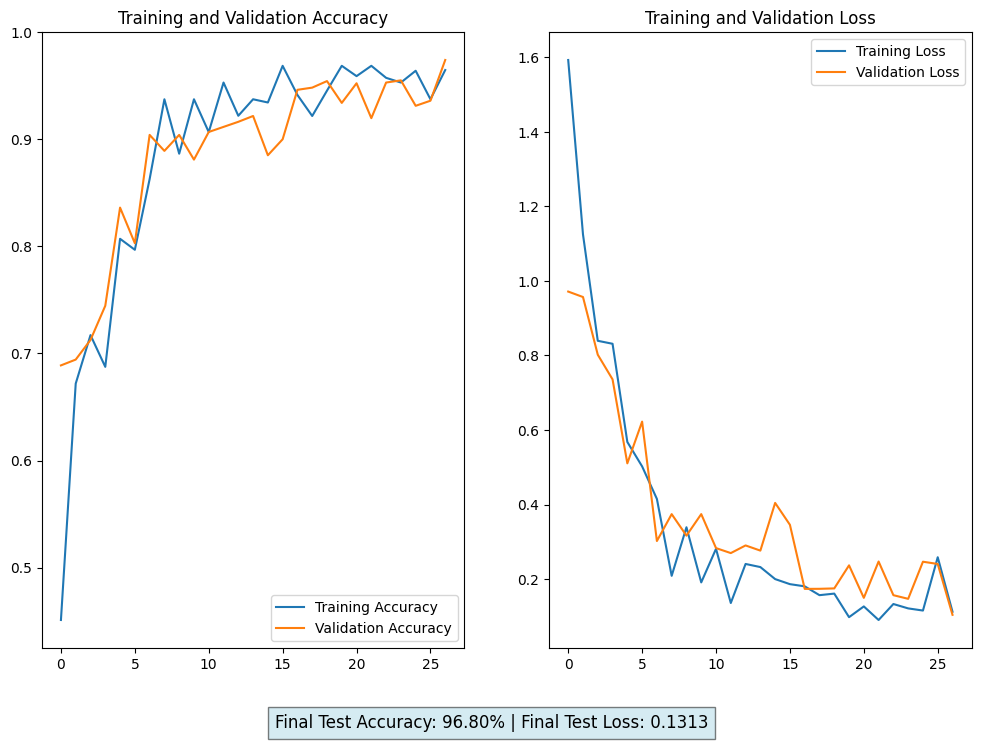

In [11]:
import matplotlib.pyplot as plt

# Mengevaluasi data test untuk mendapatkan angka pastinya
print("Sedang mengevaluasi data test untuk mendapatkan hasil akhir...\n")
test_loss, test_acc = model.evaluate(test_generator, verbose=0)

# Mengambil angka pada epoch terakhir (hasil akhir training & validation)
train_acc = history.history['accuracy'][-1]
train_loss = history.history['loss'][-1]
val_acc = history.history['val_accuracy'][-1]
val_loss = history.history['val_loss'][-1]

# MENCETAK HASIL ANGKA (TEKS)
print("="*45)
print("HASIL AKHIR EVALUASI MODEL")
print("="*45)
print(f"Data Training   -> Akurasi: {train_acc*100:.2f}% | Loss: {train_loss:.4f}")
print(f"Data Validation -> Akurasi: {val_acc*100:.2f}% | Loss: {val_loss:.4f}")
print(f"Data Testing    -> Akurasi: {test_acc*100:.2f}% | Loss: {test_loss:.4f}")
print("="*45 + "\n")

# MEMBUAT GRAFIK (PLOT)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 8))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

# keterangan Test Score
plt.figtext(0.5, 0.01, f"Final Test Accuracy: {test_acc*100:.2f}% | Final Test Loss: {test_loss:.4f}",
            ha="center", fontsize=12, bbox={"facecolor":"lightblue", "alpha":0.5, "pad":5})

# Menampilkan semua visualisasi
plt.show()

In [12]:

# Membuat direktori utama untuk submission
base_sub_dir = '/content/submission'
saved_model_dir = os.path.join(base_sub_dir, 'saved_model')
os.makedirs(saved_model_dir, exist_ok=True)

# Menyimpan model ke format SavedModel menggunakan fungsi export terbaru
model.export(saved_model_dir)

print("Model berhasil disimpan dalam format SavedModel di folder:", saved_model_dir)

Saved artifact at '/content/submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  133299000709136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133299000709712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133299000709328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133299000711824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133299000711056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133299000712784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133299000712208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133299000712400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133299000712592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133299000713744: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [13]:
import tensorflow as tf

# Menyiapkan folder tflite
tflite_dir = os.path.join(base_sub_dir, 'tflite')
os.makedirs(tflite_dir, exist_ok=True)

# Melakukan konversi dari SavedModel ke TF-Lite
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
tflite_model = converter.convert()

# Menyimpan file model.tflite
with open(os.path.join(tflite_dir, 'model.tflite'), 'wb') as f:
    f.write(tflite_model)

# Mengambil nama kelas dan menyimpannya ke label.txt
labels = '\n'.join(sorted(train_generator.class_indices.keys()))
with open(os.path.join(tflite_dir, 'label.txt'), 'w') as f:
    f.write(labels)

print("Model TF-Lite dan label.txt sudah tersimpan di folder:", tflite_dir)

Model TF-Lite dan label.txt sudah tersimpan di folder: /content/submission/tflite


In [1]:
# Install library tensorflowjs
!pip install tensorflowjs
import os
import shutil

# letak direktori
base_sub_dir = '/content/submission'
saved_model_dir = os.path.join(base_sub_dir, 'saved_model')

# Menyiapkan folder tfjs_model
tfjs_dir = os.path.join(base_sub_dir, 'tfjs_model')

if os.path.exists(tfjs_dir):
    shutil.rmtree(tfjs_dir)

!tensorflowjs_converter --input_format=tf_saved_model --weight_shard_size_bytes 50000000 {saved_model_dir} {tfjs_dir}

print("\nModel TFJS sudah tersimpan di folder:", tfjs_dir)
print("Isi folder TFJS saat ini:", os.listdir(tfjs_dir))

2026-02-22 06:56:10.838750: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771743370.872311    7152 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771743370.883434    7152 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771743370.910105    7152 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771743370.910138    7152 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771743370.910146    7152 computation_placer.cc:177] computation placer alr

In [2]:
import shutil

# Membuat file requirements.txt
!pip freeze > /content/requirements.txt

In [3]:
# Jalankan ini lagi agar zip-nya ter-update
import shutil
shutil.make_archive('/content/submission', 'zip', '/content/submission')
print("File submission.zip berhasil di-update!")

File submission.zip berhasil di-update!


Silakan unggah 1 gambar sayuran untuk dites:


Saving kentang.jpg to kentang.jpg


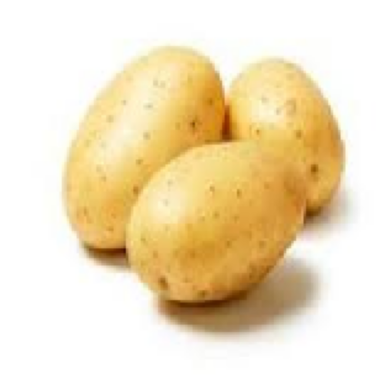


--- BUKTI INFERENSI (TF-LITE) ---
Nama File      : kentang.jpg
Tebakan Model  : POTATO
Keyakinan      : 100.00%


In [5]:
import numpy as np
import tensorflow as tf
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Membaca daftar nama kelas
label_path = '/content/submission/tflite/label.txt'
with open(label_path, 'r') as f:
    class_names = f.read().splitlines()

# Memuat model TF-Lite dari folder submission
tflite_model_path = '/content/submission/tflite/model.tflite'
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

# Mendapatkan detail input dan output model TF-Lite
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Silakan unggah 1 gambar sayuran untuk dites:")
uploaded = files.upload()

for fn in uploaded.keys():
    # Load gambar dan ubah ukuran
    img = image.load_img(fn, target_size=(150, 150))

    # Menampilkan gambar yang diunggah
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Mengubah gambar menjadi array dan normalisasi
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0

    # Set tensor input
    interpreter.set_tensor(input_details[0]['index'], x)
    # Jalankan prediksi
    interpreter.invoke()
    # Ambil hasil dari tensor output
    predictions = interpreter.get_tensor(output_details[0]['index'])[0]

    # Mendapatkan nama kelas
    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = np.max(predictions) * 100

    print(f"\n--- BUKTI INFERENSI (TF-LITE) ---")
    print(f"Nama File      : {fn}")
    print(f"Tebakan Model  : {predicted_class.upper()}")
    print(f"Keyakinan      : {confidence:.2f}%")